# RPG Advanced Metadata Mapper

This notebook provides a flexible way to inventory legacy files with different extensions and positional naming conventions.

### Step 1: Configuration
Support for multiple extensions and source directories.

In [1]:
import os
import pandas as pd
from pathlib import Path
from datetime import datetime

SOURCE_DIR = "../src"
EXTENSIONS = [".rpgle", ".rpg", ".clle", ".sqlrpgle", ".dds"]

### Step 2: Flexible Positional Config
Define **where** the metadata is in the filename. 
- `pos`: 'start', 'end', or a tuple `(start, end)` for substring indexing.
- `len`: length of the segment (required for 'start' and 'end').
- `map`: (Optional) Dictionary to translate codes to business names.

In [2]:
METADATA_CONFIG = {
    "Subsystem": {
        "pos": "start", 
        "len": 3, 
        "map": {
            "ORD": "Orders",
            "INV": "Inventory",
            "GLC": "Finance",
            "SYS": "System"}
    },
    "Module": {
        "pos": (3, 5), # Substring index [3:5]
        "map": {
            "EN": "Entry",
            "WH": "Warehouse",
            "AC": "Accounting",
            "PR": "Reporting"}
    },
    "Program_Type": {
        "pos": "end", 
        "len": 2, 
        "map": {
            "RP": "RPG-ILE",
            "CL": "Control Lang",
            "LF": "Data View"}
    }
}

In [3]:
def extract_segment(name, config):
    """Extracts a segment from the filename based on position config."""
    pos = config.get("pos")
    length = config.get("len", 0)
    
    if pos == "start":
        code = name[:length]
    elif pos == "end":
        code = name[-length:]
    elif isinstance(pos, tuple):
        code = name[pos[0]:pos[1]]
    else:
        code = ""
    
    code = code.strip()
    
    mapping = config.get("map", {})
    return mapping.get(code, f"Unknown [{code}]" if code else "N/A")

def count_lines(file_path):
    """Count total and non-empty lines in a file."""
    try:
        with open(file_path, "r", encoding="utf-8", errors="replace") as f:
            lines = f.readlines()
        total = len(lines)
        non_empty = sum(1 for l in lines if l.strip())
        return total, non_empty
    except Exception:
        return 0, 0

def analyze_file(file_path):
    name_only = file_path.stem
    name_padded = name_only.ljust(10)
    
    total_lines, non_empty_lines = count_lines(file_path)
    
    result = {
        "Filename": file_path.name,
        "Ext": file_path.suffix.upper(),
        "Total_Lines": total_lines,
        "Code_Lines": non_empty_lines,
    }
    
    for field, config in METADATA_CONFIG.items():
        result[field] = extract_segment(name_padded, config)
        
    return result

# Scan recursively; match extensions case-insensitively
src_path = Path(SOURCE_DIR)
files = [
    f for f in src_path.rglob("*")
    if f.is_file() and f.suffix.lower() in EXTENSIONS
]

df = pd.DataFrame([analyze_file(f) for f in files])
print(f"Found {len(df)} files")
df

Found 356 files


,Filename,Ext,Total_Lines,Code_Lines,Subsystem,Module,Program_Type
0,dataqueue.rpgle,.RPGLE,91,66,Unknown [dat],Unknown [aq],Unknown [e]
1,mixedWidth.rpgle,.RPGLE,4,4,Unknown [mix],Unknown [ed],Unknown [th]
2,abs.rpgle,.RPGLE,11,10,Unknown [abs],N/A,N/A
3,addr.rpgle,.RPGLE,10,9,Unknown [add],Unknown [r],N/A
4,alloc.rpgle,.RPGLE,11,10,Unknown [all],Unknown [oc],N/A
...,...,...,...,...,...,...,...
351,MTNCUSTR.SQLRPGLE,.SQLRPGLE,860,772,Unknown [MTN],Unknown [CU],N/A
352,USADRVAL.SQLRPGLE,.SQLRPGLE,139,125,Unknown [USA],Unknown [DR],N/A
353,USADRVAL_T.RPGLE,.RPGLE,174,139,Unknown [USA],Unknown [DR],Unknown [_T]
354,RCC.CLLE,.CLLE,82,69,Unknown [RCC],N/A,N/A


### Step 3: Distribution Analysis
Quickly see how your code is distributed across the system.

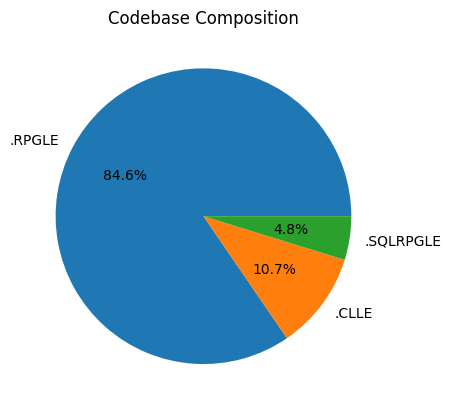

In [4]:
import matplotlib.pyplot as plt

# Breakdown by Extension
df['Ext'].value_counts().plot(kind='pie', title='Codebase Composition', autopct='%1.1f%%')
plt.show()

In [5]:
# Crosstab of Subsystem vs Module
pd.crosstab(df['Subsystem'], df['Module'], margins=True)

Module,Entry,N/A,Unknown [2],Unknown [AM],Unknown [AR],Unknown [AS],Unknown [AT],Unknown [BK],Unknown [BN],Unknown [BY],...,Unknown [th],Unknown [ti],Unknown [tr],Unknown [ul],Unknown [ur],Unknown [wo],Unknown [xo],Unknown [y],Unknown [y_],All
Subsystem,,,,,,,,,,,,,,,,,,,,,
Unknown [ACQ],0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Unknown [ADD],0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
Unknown [AID],0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
Unknown [ALI],0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Unknown [ALL],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unknown [und],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Unknown [unn],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Unknown [whe],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


### Step 4: Line Count Analysis
Visualize how large each file is in terms of total and non-empty (code) lines.

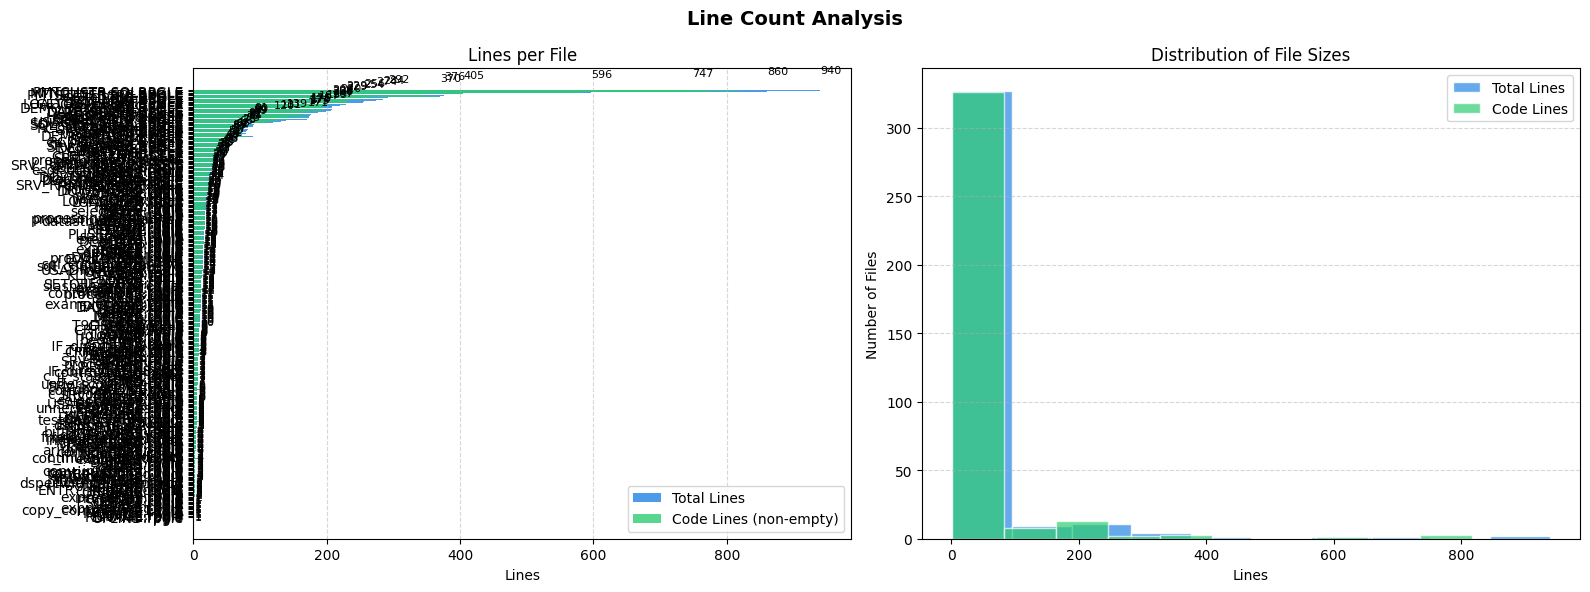


📊 Line Count Summary:
                            Filename  Total_Lines  Code_Lines
                   PMTCUSTR.SQLRPGLE          940         818
                   MTNCUSTR.SQLRPGLE          860         772
                   MTNCUSTR.SQLRPGLE          747         738
                  PMTSTATER.SQLRPGLE          596         578
                     SRTUSRSPC.RPGLE          405         405
                           T1R.RPGLE          376         347
                      GETOBJUR.RPGLE          370         366
                           PRT.RPGLE          292         265
                       SRV_MSG.RPGLE          284         251
                      DATEADJR.RPGLE          274         234
                  LOADCUSTR.SQLRPGLE          256         230
                   GETOBJUR.SQLRPGLE          254         230
                        LCKOBJC.CLLE          229         202
                        LCKOBJC.CLLE          229         202
                         PRT_T.RPGLE          2

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Line Count Analysis", fontsize=14, fontweight="bold")

# --- Left: Bar chart per file ---
df_sorted = df.sort_values("Total_Lines", ascending=True)
short_names = df_sorted["Filename"].apply(lambda x: x[:20])

axes[0].barh(short_names, df_sorted["Total_Lines"], color="#4C9BE8", label="Total Lines")
axes[0].barh(short_names, df_sorted["Code_Lines"], color="#2ECC71", alpha=0.8, label="Code Lines (non-empty)")
axes[0].set_xlabel("Lines")
axes[0].set_title("Lines per File")
axes[0].legend()
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

# Annotate total line count
for i, (total, code) in enumerate(zip(df_sorted["Total_Lines"], df_sorted["Code_Lines"])):
    axes[0].text(total + 0.5, i, str(total), va="center", fontsize=8)

# --- Right: Histogram of file sizes ---
axes[1].hist(df["Total_Lines"], bins=10, color="#4C9BE8", edgecolor="white", alpha=0.85, label="Total Lines")
axes[1].hist(df["Code_Lines"], bins=10, color="#2ECC71", edgecolor="white", alpha=0.7, label="Code Lines")
axes[1].set_xlabel("Lines")
axes[1].set_ylabel("Number of Files")
axes[1].set_title("Distribution of File Sizes")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Summary stats
print("\n📊 Line Count Summary:")
print(df[["Filename", "Total_Lines", "Code_Lines"]].sort_values("Total_Lines", ascending=False).to_string(index=False))
print(f"\nTotal lines across all files : {df['Total_Lines'].sum():,}")
print(f"Total code lines (non-empty) : {df['Code_Lines'].sum():,}")
print(f"Average lines per file       : {df['Total_Lines'].mean():.1f}")
print(f"Largest file                 : {df.loc[df['Total_Lines'].idxmax(), 'Filename']} ({df['Total_Lines'].max()} lines)")